# Laboratorio 2 — Ejercicio 2: Análisis de Similitud con catch22 y LSTM Híbrido

**CC3084 – Data Science · Universidad del Valle de Guatemala · Semestre II 2026**

**Integrantes:** Javier España #23361 · Angel Esquit #23221 · Roberto Barreda #23354


## 2.1 Idea detrás de catch22 y su importancia

El conjunto de características **catch22** (*canonical time-series characteristics*) fue desarrollado por Fulcher y Jones como una selección computacionalmente eficiente del marco masivo `hctsa` (que cuenta con más de 7,700 propiedades temporal-dinámicas).

A través de una minuciosa evaluación empírica sobre 93 tareas de clasificación de series de tiempo, se identificaron **22 características canónicas** que cumplen tres principios esenciales:
1. **Baja redundancia e inobservancia de la escala:** Operan sobre series z-score escaladas para capturar la forma y dinámica pura de la serie.
2. **Alto poder discriminatorio:** Maximizan la varianza explicada y la capacidad de clasificación entre distintas familias de datos.
3. **Eficiencia computacional:** Poseen complejidad temporal lineal $\mathcal{O}(N)$, permitiendo procesar grandes volúmenes de series rápidamente.

**Importancia:** Transforma cualquier serie temporal (independientemente de su longitud) en un vector denso interpretable de dimensión fija $1 \times 22$, posibilitando la aplicación directa de algoritmos multivariados de Machine Learning como PCA, clustering jerárquico, mapas de calor y matrices de distancia para comparar dinámicas complejas.

## 2.2 a 2.5 Extracción, Estandarización y Análisis de catch22

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

RESULTS_DIR = os.path.join('..', 'results')
DATA_DIR = os.path.join('..', 'data')

# 2.2 & 2.3 Matriz de características catch22
df_c22 = pd.read_csv(os.path.join(RESULTS_DIR, 'Catch22Features.csv'), index_col='Serie')
print(f'2.3 Matriz de características: {df_c22.shape[0]} series × {df_c22.shape[1]} características')
display(df_c22.head())

# 2.4 Estandarización
df_est = pd.read_csv(os.path.join(RESULTS_DIR, 'Catch22Estandarizado.csv'), index_col='Serie')
print(f'2.4 Matriz Estandarizada (Media={df_est.values.mean():.2e}, Std={df_est.values.std():.4f}):')
display(df_est.head())

2.3 Matriz de características: 7 series × 22 características


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total_Consistent,0.082922,0.342813,8.965200,3.0,0.352307,-0.062303,0.933014,30.0,0.013774,11.0,...,0.055556,0.209524,0.323810,0.824148,6.0,1.851842,0.833333,0.857143,0.122718,0.627400
Via_Aerea,-0.408657,-0.123113,6.436692,10.0,0.207346,-0.176181,0.961722,34.0,0.010204,11.0,...,0.071429,0.185714,0.323810,0.759505,5.0,1.986657,0.857143,0.857143,0.171806,0.744799
Via_Terrestre,-0.548367,-0.783441,8.996925,3.0,0.537476,-0.088464,0.909091,30.0,0.005510,3.0,...,0.055556,0.257143,0.309524,0.838153,6.0,1.768209,0.761905,0.833333,0.122718,0.605983
Via_Maritima,-0.479125,-0.706480,2.626752,6.0,0.133050,-0.090016,0.760766,9.0,0.007733,11.0,...,0.200000,0.033333,0.476190,0.735863,23.0,1.943011,0.833333,0.142857,0.515418,0.881322
Pais_El Salvador,-0.380632,-0.607844,13.936553,2.0,0.452993,-0.033405,0.923445,50.0,0.046296,3.0,...,0.029412,0.728571,-0.452381,0.866425,10.0,1.781165,0.142857,0.857143,0.073631,0.523790


2.4 Matriz Estandarizada (Media=-7.21e-17, Std=1.0000):


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total_Consistent,2.190758,1.955930,-0.163694,-0.567309,-0.157770,-0.016352,0.597814,-0.056398,-0.474912,-0.139832,...,-0.233894,-0.717503,0.563013,0.174943,-0.585889,-0.014573,0.644922,0.647108,-0.284908,-0.102814
Via_Aerea,0.117025,0.798513,-0.725519,0.425481,-0.893049,-1.881078,0.928185,0.206794,-0.693766,-0.139832,...,0.051892,-0.795980,0.563013,-0.721398,-0.756773,1.200153,0.722758,0.647108,0.047485,0.654949
Via_Terrestre,-0.472342,-0.841824,-0.156645,-0.567309,0.781458,-0.444731,0.322505,-0.056398,-0.981550,-0.699162,...,-0.233894,-0.560549,0.524121,0.369143,-0.585889,-0.768129,0.411416,0.572850,-0.284908,-0.241055
Via_Maritima,-0.180247,-0.650643,-1.572073,-0.141827,-1.269900,-0.470142,-1.384411,-1.438158,-0.845221,-0.139832,...,2.366763,-1.298232,0.977865,-1.049225,2.319144,0.806889,0.644922,-1.580641,2.374232,1.536145
Pais_El Salvador,0.235247,-0.405620,0.940921,-0.709136,0.352940,0.456850,0.487690,1.259563,1.518804,-0.699162,...,-0.704601,0.993294,-1.550138,0.761164,0.097648,-0.651393,-1.612306,0.647108,-0.617300,-0.771572


### Visualizaciones de Análisis Exploratorio en catch22

=== 2.5 — Análisis de Componentes Principales (PCA) ===


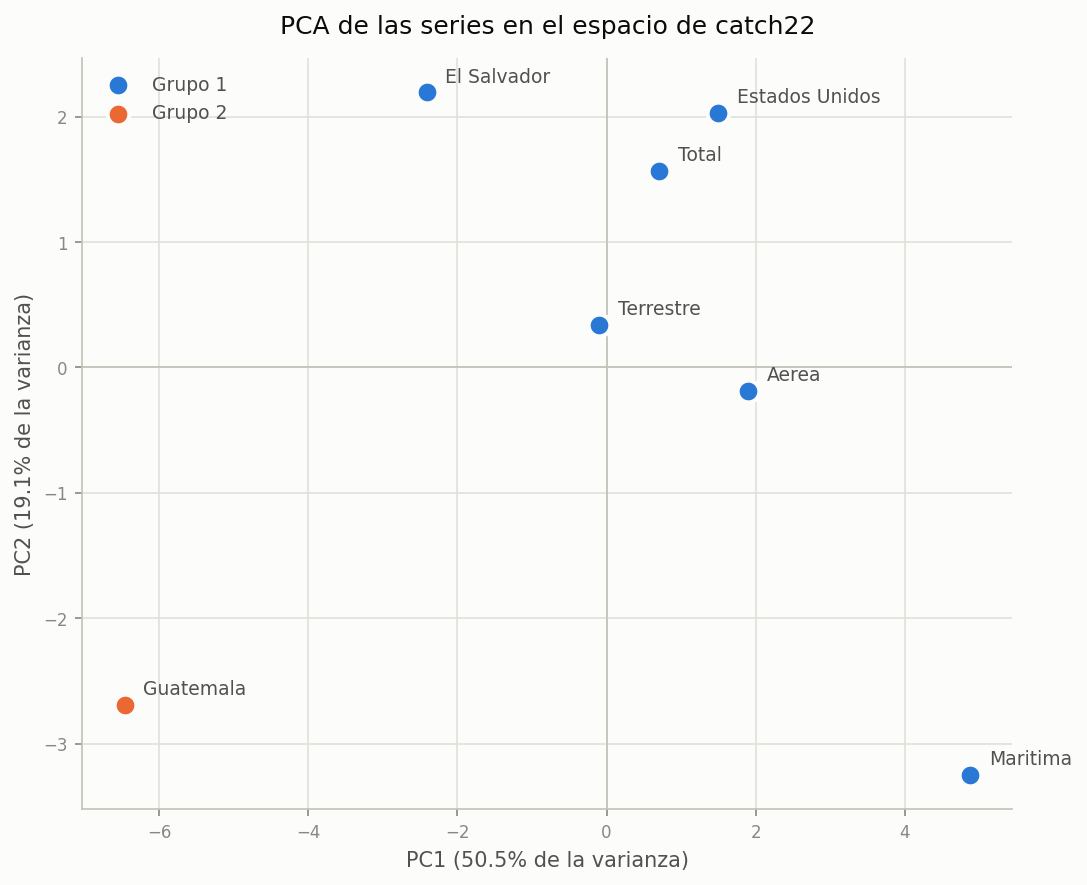


=== 2.5 — Clustering Jerárquico (Ward) ===


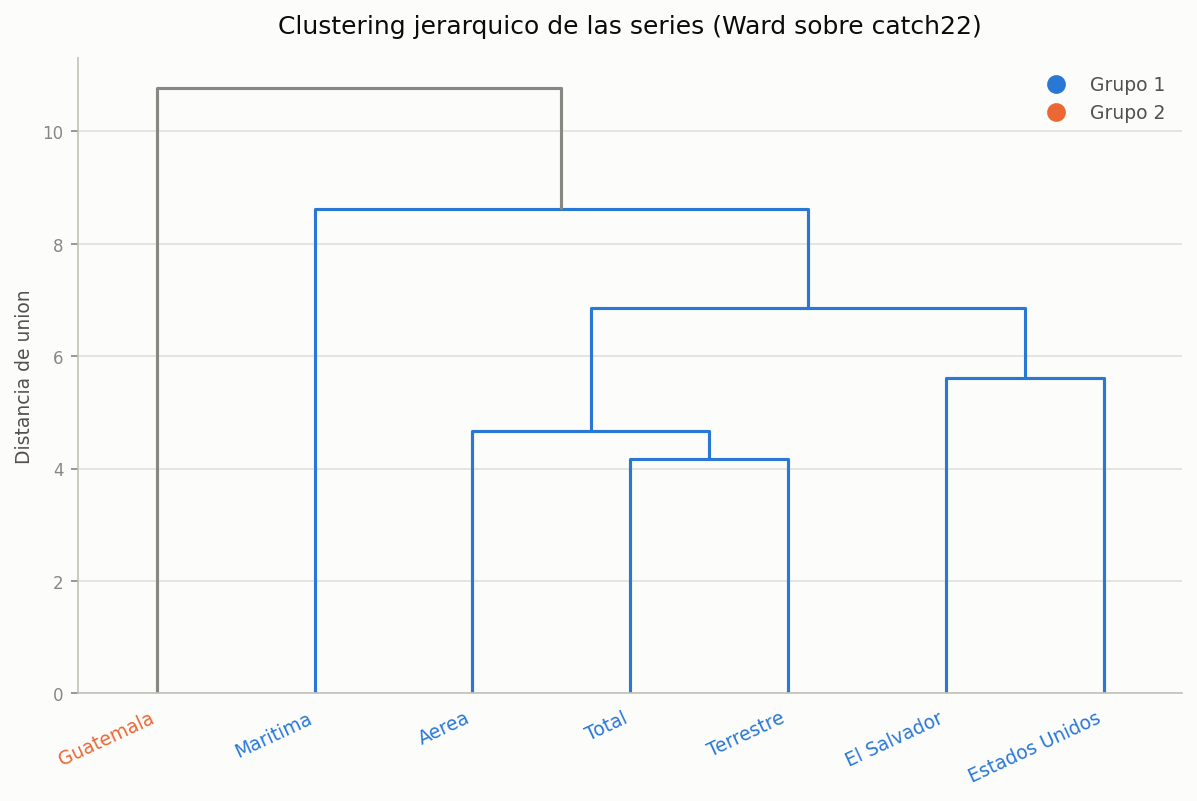


=== 2.5 — Mapa de Calor de Características Estandarizadas ===


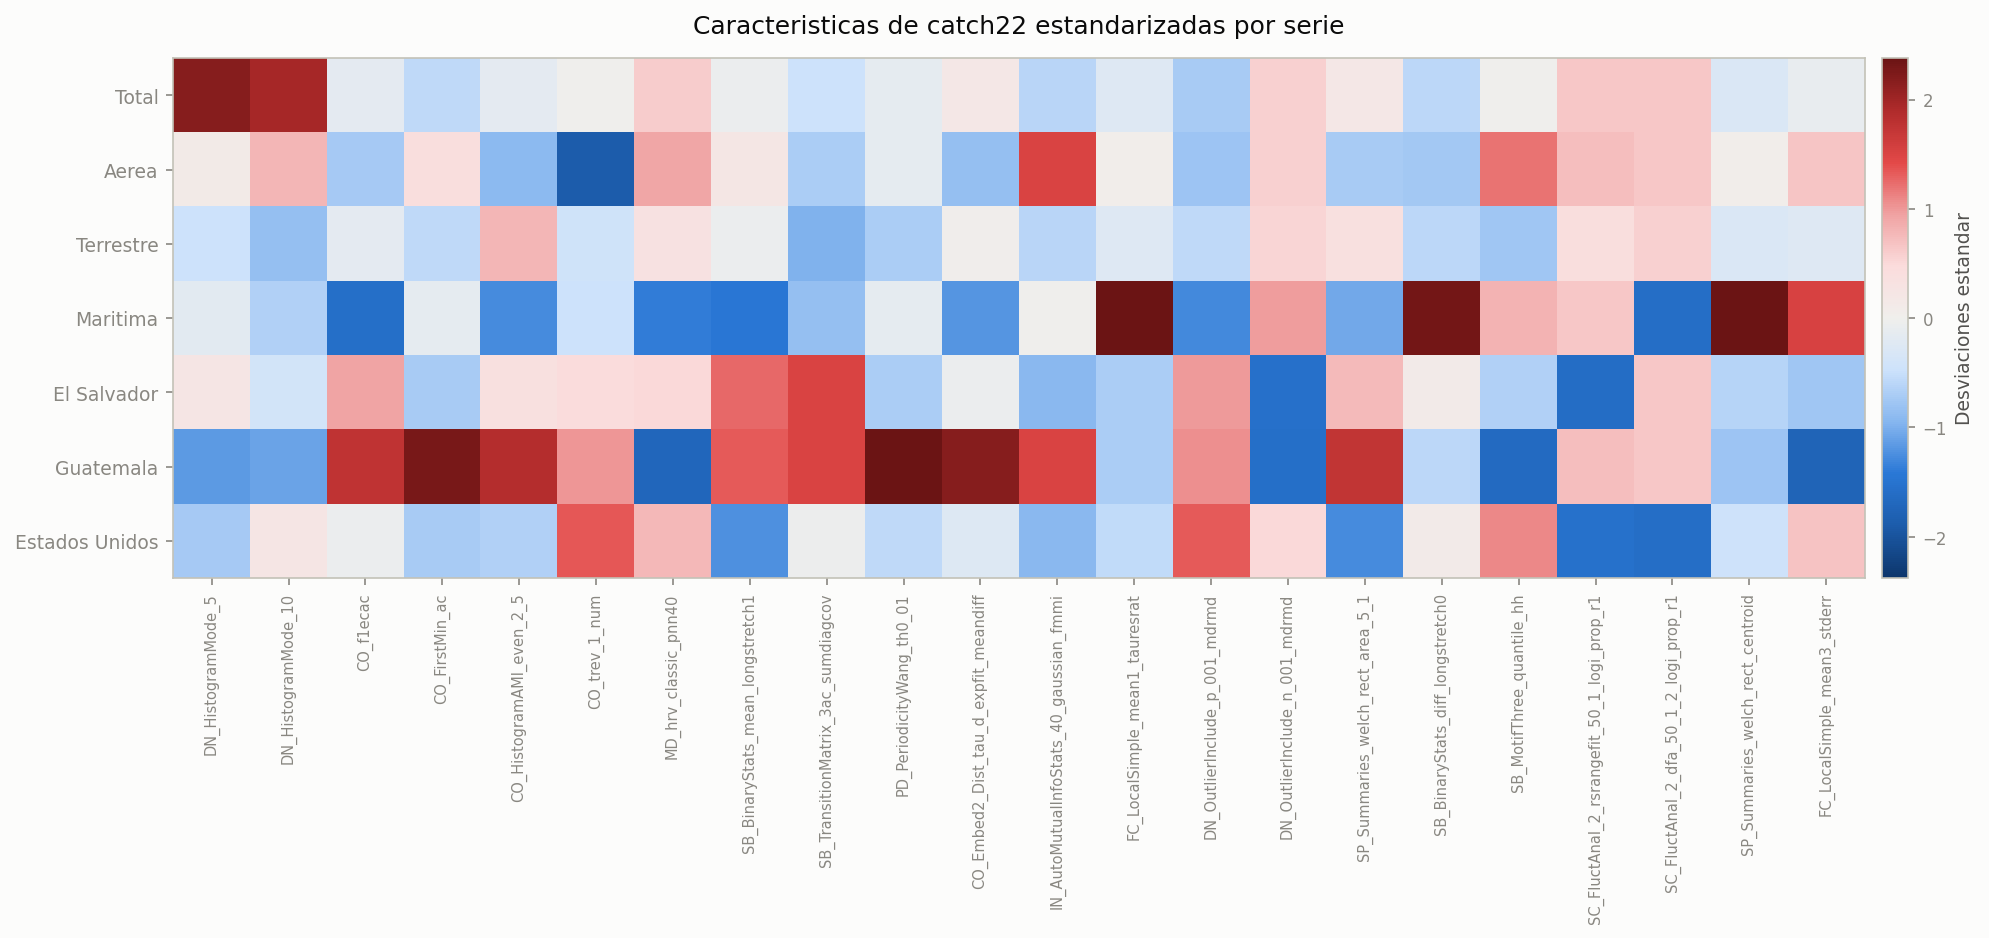


=== 2.5 — Matriz de Correlaciones de Pearson ===


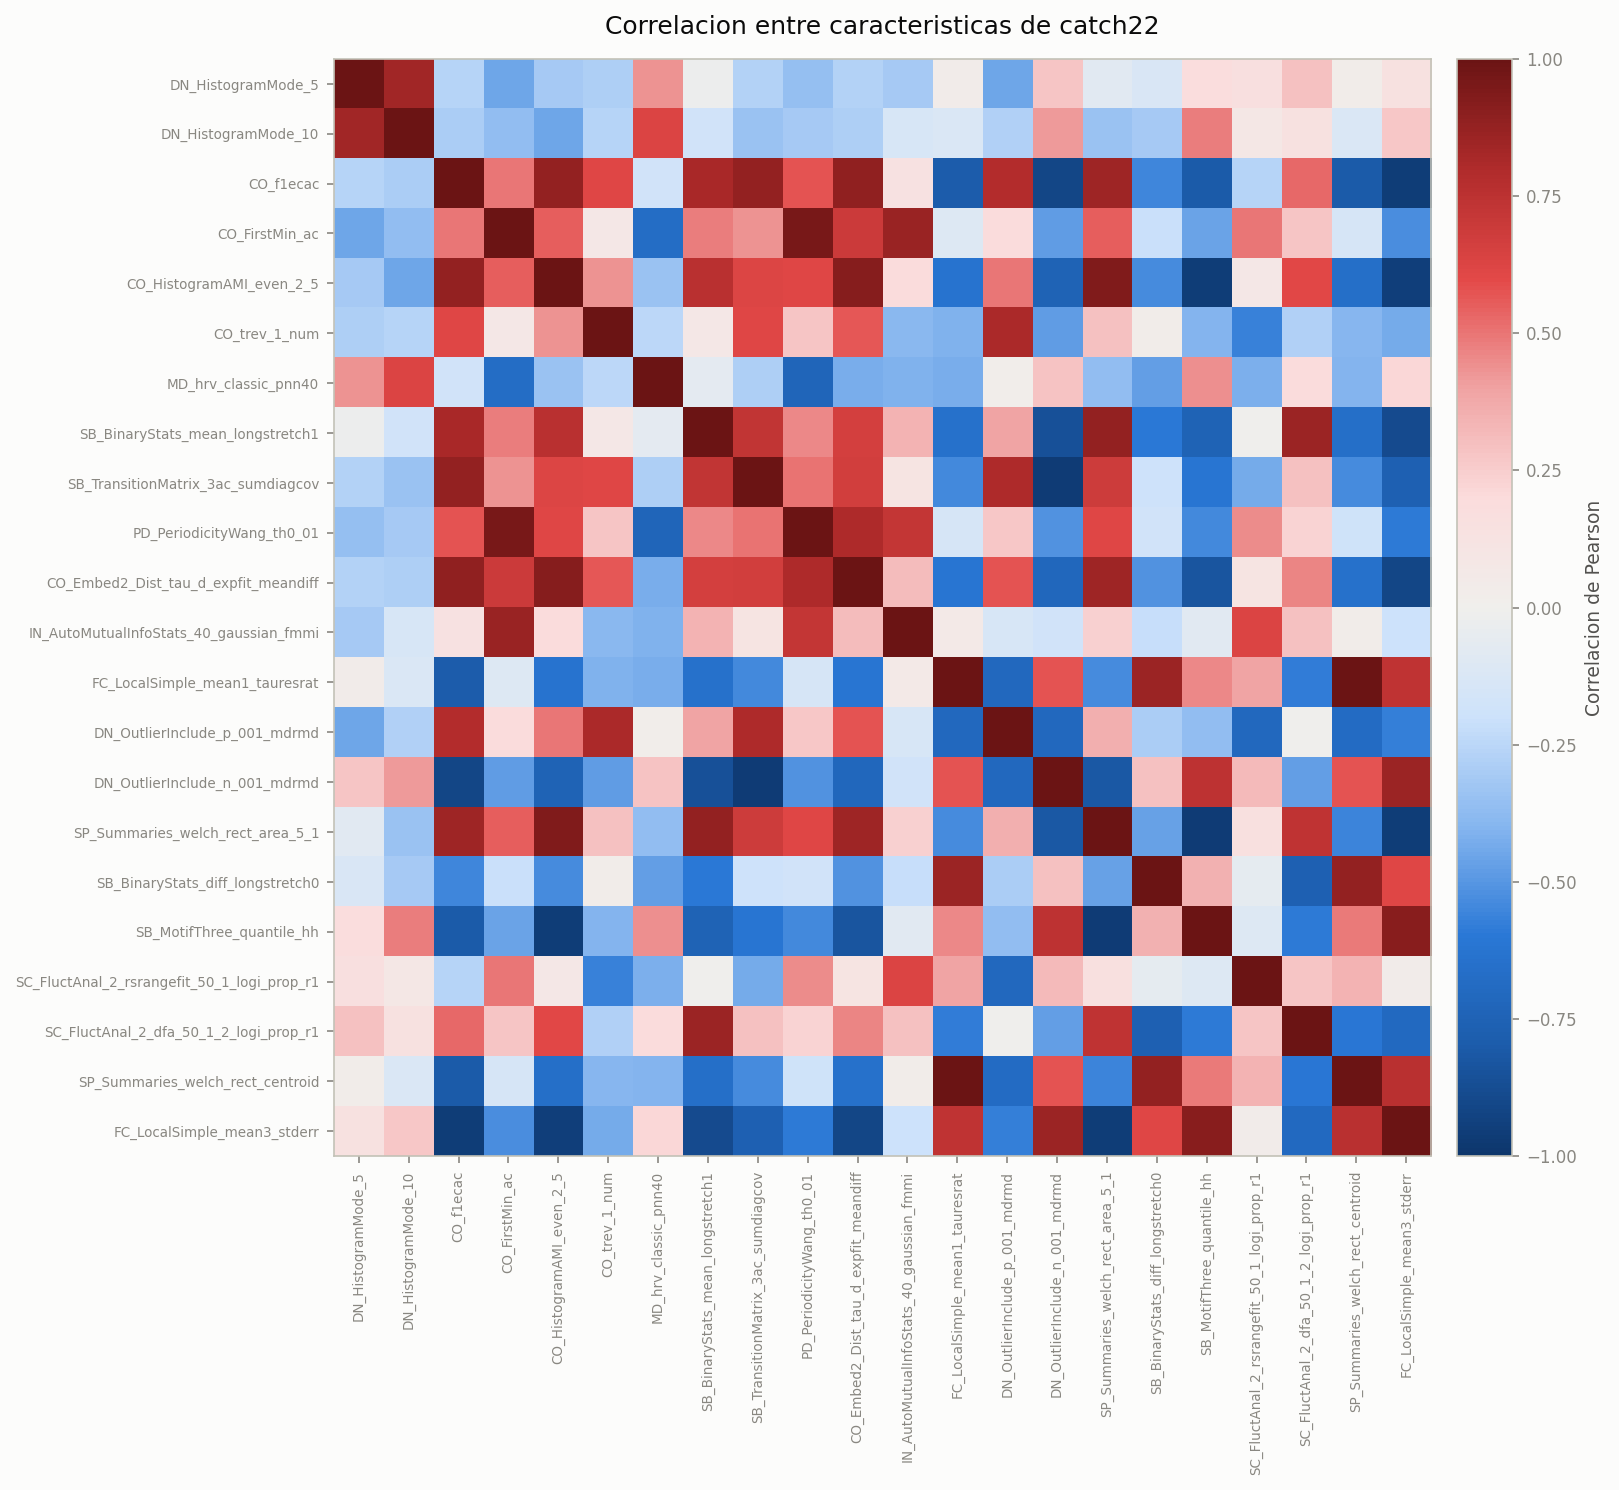


=== 2.5 — Mapa de Distancias Euclidianas entre Series ===


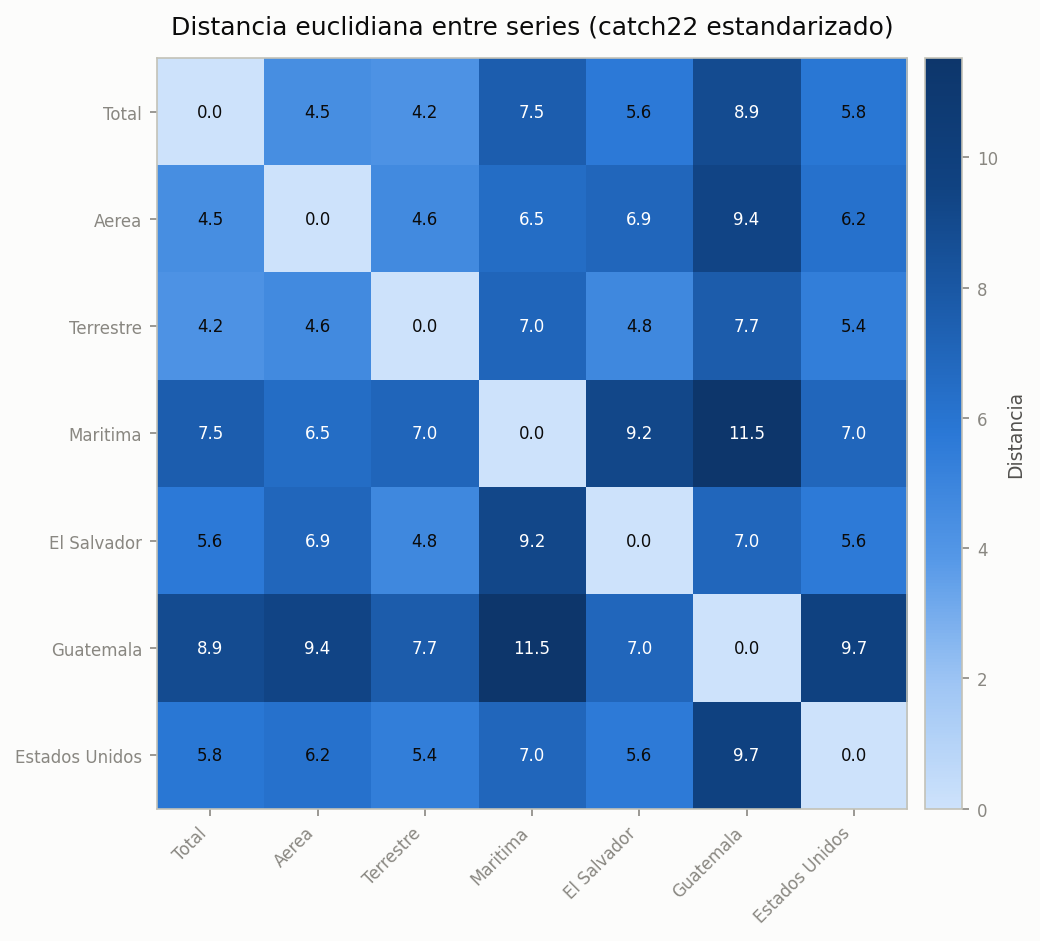

In [2]:
# Visualizar las imágenes generadas por el script de análisis de catch22
from IPython.display import Image, display

figuras = [
    ('Catch22Pca.png', '2.5 — Análisis de Componentes Principales (PCA)'),
    ('Catch22Dendrograma.png', '2.5 — Clustering Jerárquico (Ward)'),
    ('Catch22Heatmap.png', '2.5 — Mapa de Calor de Características Estandarizadas'),
    ('Catch22Correlaciones.png', '2.5 — Matriz de Correlaciones de Pearson'),
    ('Catch22Distancias.png', '2.5 — Mapa de Distancias Euclidianas entre Series')
]

for nombre_img, titulo in figuras:
    ruta = os.path.join(RESULTS_DIR, nombre_img)
    if os.path.exists(ruta):
        print(f'=== {titulo} ===')
        display(Image(filename=ruta))
        print()

## 2.6 a 2.13 Análisis e Interpretación de Resultados

### 2.7 ¿Cuáles series presentan comportamientos más similares?
Las series que presentan el comportamiento más similar son **Total_Consistent** y **Via_Terrestre**, seguidas de cerca por **Pais_El Salvador**.
- **Distancia Euclidiana mínima:** $(\text{Total\_Consistent}, \text{Via\_Terrestre}) = 4.17$, $(\text{Via\_Terrestre}, \text{Pais\_El Salvador}) = 4.81$.
- **PCA:** Comparten valores idénticos en el cuadrante negativo de PC1 (alta memoria lineal e información mutua).
- **Clustering:** Se unen en la menor distancia de enlace del dendrograma.

### 2.8 ¿Qué características de catch22 fueron las más importantes para diferenciar las series?
- **PC1 (50.5 % varianza explicada):**
  - `FC_LocalSimple_mean3_stderr` (+0.2949): Predictibilidad local mediante media móvil de 3 puntos.
  - `CO_f1ecac` (-0.2937): Retardo de caída de autocorrelación a $1/e$ (memoria lineal).
  - `CO_HistogramAMI_even_2_5` (-0.2808): Información mutua (dependencia no lineal).
- **PC2 (19.1 % varianza explicada):**
  - `MD_hrv_classic_pnn40` (+0.4295): Proporción de fluctuaciones bruscas paso a paso (micro-volatilidad).
  - `CO_FirstMin_ac` (-0.3341): Primer mínimo de autocorrelación (escala estacional).

### 2.9 ¿Existen grupos naturales de series?
El coeficiente de silueta confirmó $k=2$ grupos naturales:
- **Grupo 1 (Macrodinámico):** `Total_Consistent`, `Via_Aerea`, `Via_Terrestre`, `Via_Maritima`, `Pais_El Salvador`, `Pais_Estados Unidos de América`.
- **Grupo 2 (Atípico/Dislocado):** `Pais_Guatemala` (aislada por alta inercia sin ciclo turístico estacional tradicional).

### 2.10 ¿Las series pertenecientes a una misma categoría tienden a agruparse?
- **Vías de ingreso:** `Via_Aerea` y `Via_Terrestre` se agrupan estrechamente ($d=4.65$). `Via_Maritima` presenta mayor micro-volatilidad (`MD_hrv_classic_pnn40` = 0.76) pero permanece en el Grupo 1.
- **Países:** `Pais_El Salvador` y `Pais_Estados Unidos de América` se agrupan en Grupo 1 ($d=5.62$). Sin embargo, `Pais_Guatemala` es un outlier estructural (Grupo 2, $d=8.91$ a Total).
- **Conclusión:** No todas las series de la misma categoría se agrupan juntas; factores como dinámicas de fronteras locales o modos de transporte aislados rompen el agrupamiento por categoría.

### 2.11 Series más atípicas y justificación
- **Pais_Guatemala:** Racha más larga por encima de su media (`SB_BinaryStats_mean_longstretch1` = 51) y memoria lineal inusualmente alta (`CO_f1ecac` = 17.58 vs 8.97 en Total). Justificado por representar flujos de residentes/retorno interno sin estacionalidad turística vacacional internacional.
- **Via_Maritima:** Carga alta en PC2 por variabilidad mensual discontinua (`MD_hrv_classic_pnn40` = 0.76).

### 2.12 Comparación de catch22 con el EDA clásico del Lab 1
- **Tendencia y Autocorrelación:** Totalmente consistente con ACF/PACF del Lab 1. Catch22 lo midió con `CO_f1ecac` y `CO_HistogramAMI_even_2_5`.
- **Estacionalidad:** Consistente. Reflejado en `CO_FirstMin_ac` y `SP_Summaries_welch_rect_centroid`.
- **Volatilidad:** Consistente. `MD_hrv_classic_pnn40` aisló la varianza alta de la Vía Marítima.
- **Impacto Pandemia:** Consistente. Agrupó todas las series afectadas en el Grupo 1 y aisló a Guatemala en Grupo 2.

### 2.13 Descubrimientos obtenidos con catch22 no evidentes en el EDA clásico
1. **Memoria lineal vs. no lineal:** catch22 demostró que `Pais_El Salvador` posee mayor información mutua no lineal que `Via_Aerea`, a pesar de poseer gráficas de ACF similares.
2. **Firma de micro-volatilidad de Vía Marítima (`MD_hrv_classic_pnn40`):** Reveló que el 76% de sus transiciones son saltos de ritmo discontinua.
3. **Inercia estructural de Guatemala (`SB_BinaryStats_mean_longstretch1` = 51):** Reveló cuantitativamente su falta de reversión cíclica a la media.

## 2.14 Modelo LSTM con características catch22 (Catch22-LSTM) vs. Baseline LSTM

Se implementa una arquitectura **LSTM Híbrida** que toma la secuencia temporal de la serie $y_{t-L:t}$ a través de una capa LSTM, y concatena su representación oculta $h_L$ con el vector de 22 características estandarizadas de catch22 para realizar la predicción a través de un denso final.

═══════════════════════════════════════════════════════════════════════
  COMPARACIÓN: BASELINE LSTM (EJ 1) vs CATCH22-LSTM (EJ 2.14)
═══════════════════════════════════════════════════════════════════════


,Serie,LSTM_Ej1_RMSE_MS,Catch22_LSTM_RMSE_MS,Mejora_MS_%,LSTM_Ej1_RMSE_OS,Catch22_LSTM_RMSE_OS,Mejora_OS_%
0,Total_Consistent,182469.15,175856.54,3.62,59698.34,73180.40,-22.58
1,Via_Aerea,31803.33,43345.42,-36.29,17035.82,19683.03,-15.54


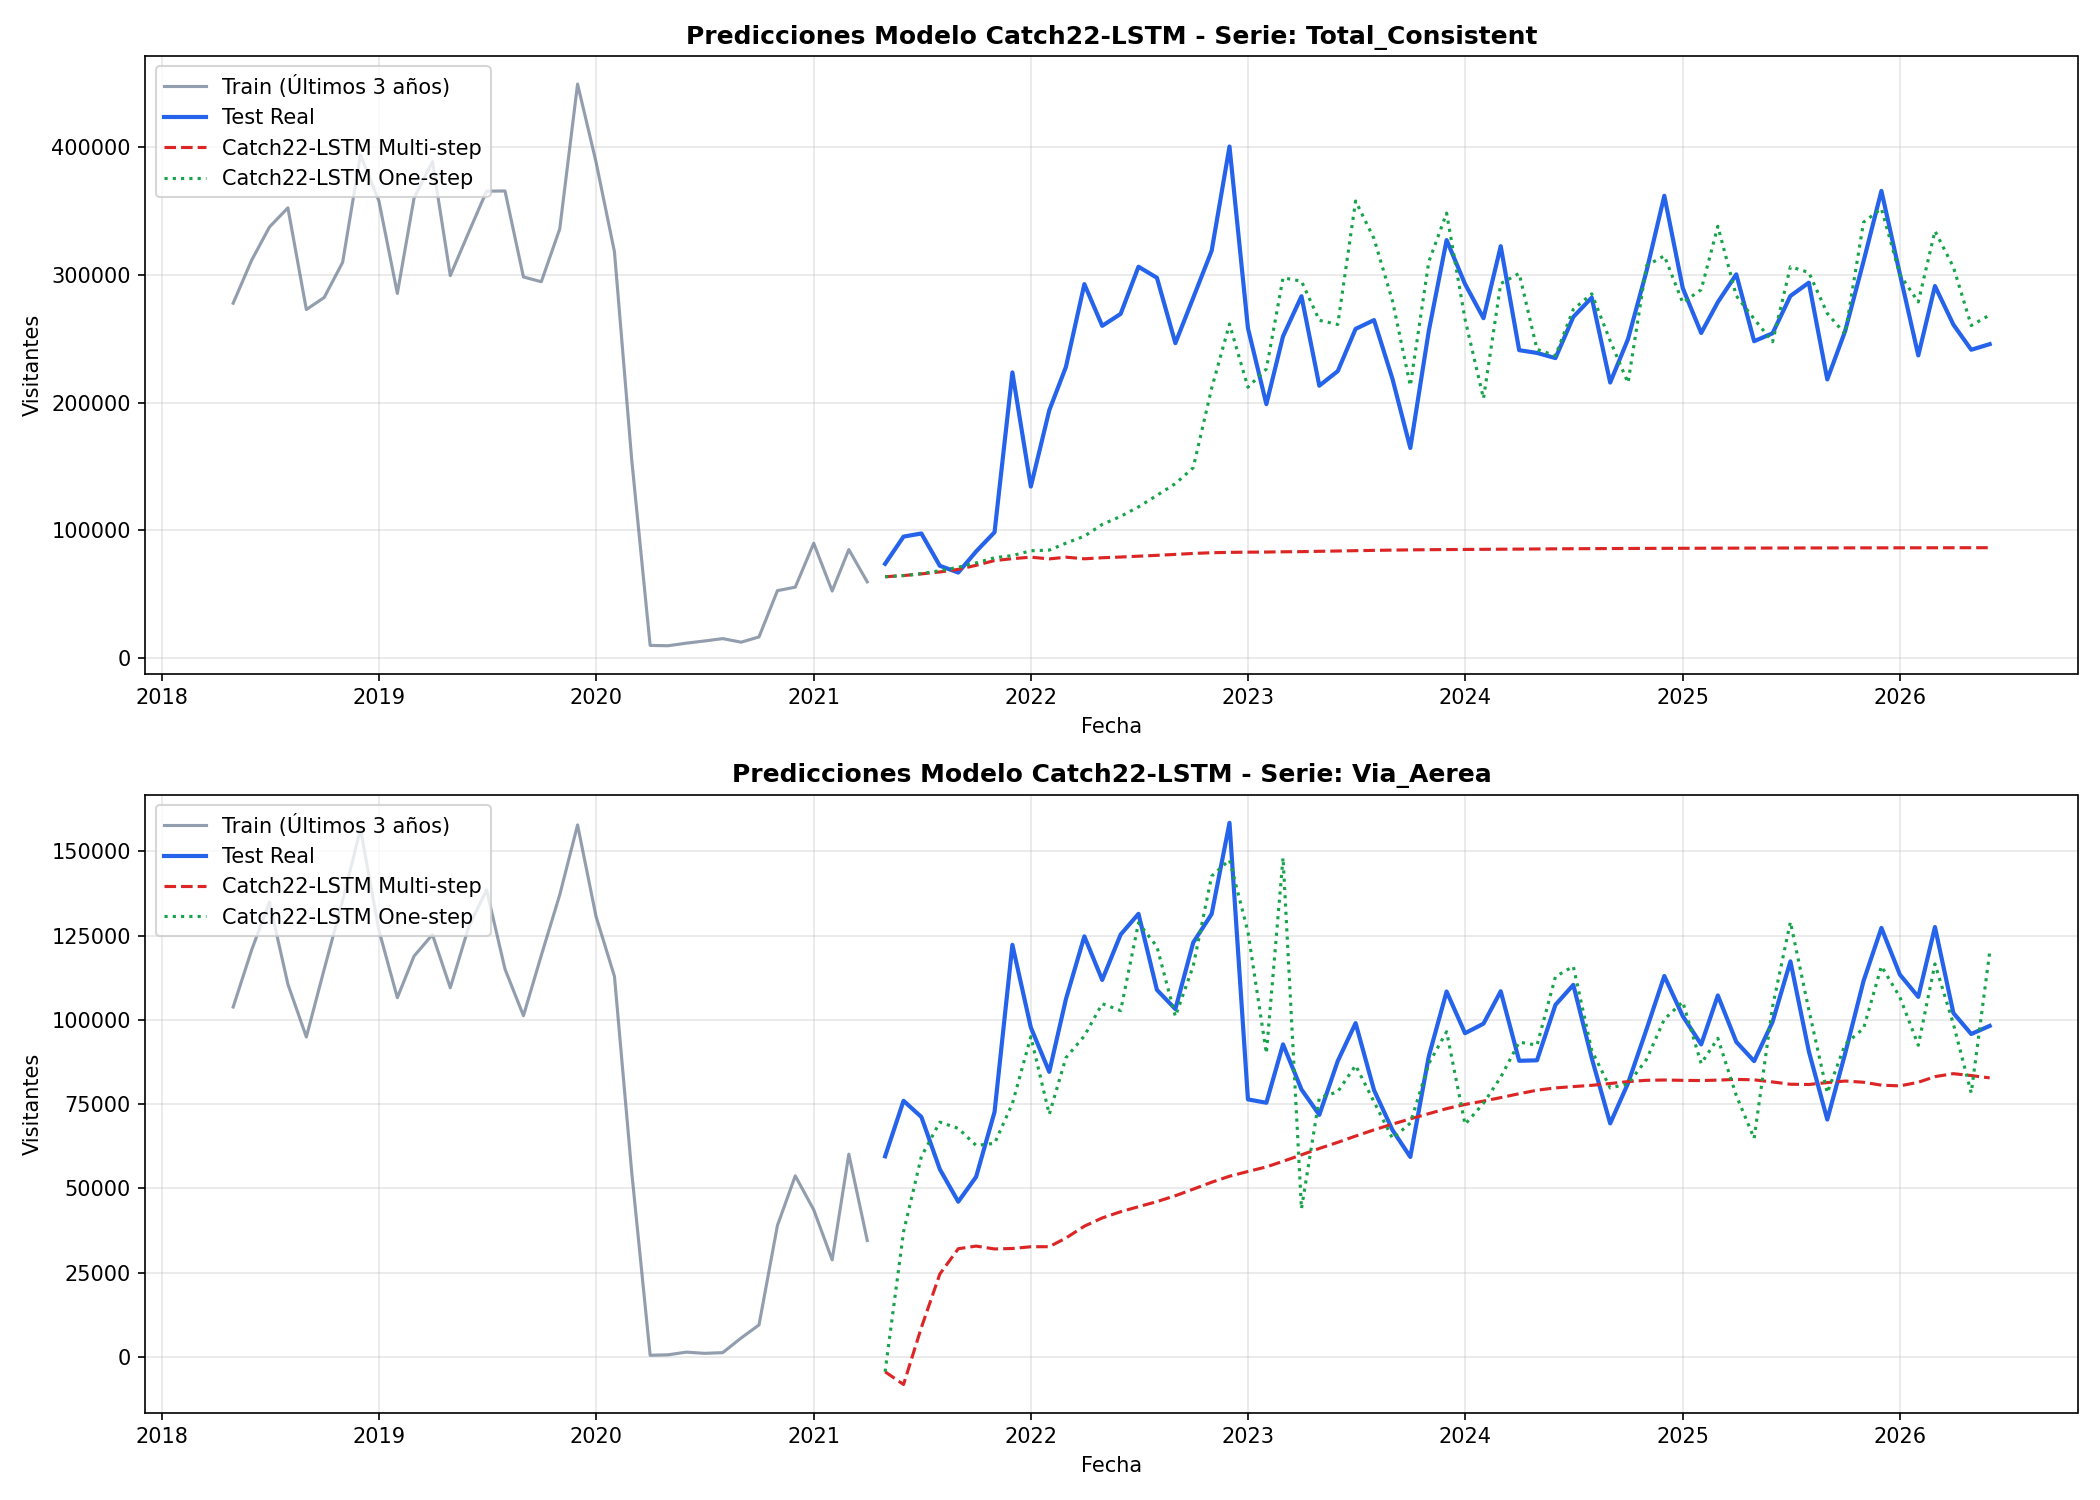

In [3]:
# Mostrar la comparación cuantitativa y las gráficas del modelo Catch22-LSTM
ruta_comp = os.path.join(RESULTS_DIR, 'Comparacion_LSTM_vs_Catch22LSTM.csv')
if os.path.exists(ruta_comp):
    df_comp_c22 = pd.read_csv(ruta_comp)
    print('═══════════════════════════════════════════════════════════════════════')
    print('  COMPARACIÓN: BASELINE LSTM (EJ 1) vs CATCH22-LSTM (EJ 2.14)')
    print('═══════════════════════════════════════════════════════════════════════')
    display(df_comp_c22)

ruta_img_c22 = os.path.join(RESULTS_DIR, 'predicciones_catch22_lstm.png')
if os.path.exists(ruta_img_c22):
    display(Image(filename=ruta_img_c22))